# Notebook 00 — Descarga de Datos Externos: NASA POWER (v2)

**Proyecto de Grado — Maestría en Ciencia de Datos**  
**Pontificia Universidad Javeriana Cali — Grupo 8**  
**Autores:** Laura García Salamanca, Daniel Sebastián Rosero Usamá, Juan Villalobos Mora

---

## Correcciones v2
El error **422 Client Error** se debía a que `CLOUD_AMT`, `T2M_MAX` y `T2M_MIN`
**no están disponibles en resolución horaria** para la comunidad RE.
Se corrigen las variables y se agrega `time-standard=UTC`.

## Variables horarias válidas (comunidad RE)

| Variable | Descripción | Unidad |
|---|---|---|
| `ALLSKY_SFC_SW_DWN` | Irradiancia solar total en superficie | W/m² |
| `CLRSKY_SFC_SW_DWN` | Irradiancia cielo despejado | W/m² |
| `T2M` | Temperatura a 2 m | °C |
| `RH2M` | Humedad relativa a 2 m | % |
| `PRECTOTCORR` | Precipitación corregida | mm/h |
| `WS10M` | Velocidad del viento a 10 m | m/s |
| `WD10M` | Dirección del viento a 10 m | grados |
| `PS` | Presión superficial | kPa |
| `SZA` | Ángulo cenital solar | grados |

El índice de claridad `KT = ALLSKY / CLRSKY` se calcula como variable derivada.


## 0. Importaciones

In [1]:
!pip install requests pandas openpyxl tqdm --quiet

import requests
import pandas as pd
import numpy as np
import os, time
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerias importadas: 2026-05-30 04:17:03


## 1. Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

RUTA_BASE  = '/content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado'
RUTA_DATOS = os.path.join(RUTA_BASE, 'datos')
os.makedirs(RUTA_DATOS, exist_ok=True)
print('Drive montado. Datos en:', RUTA_DATOS)

Mounted at /content/drive
Drive montado. Datos en: /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos


## 2. Configuracion de parametros

In [3]:
LAT = 1.2136
LON = -77.2986

# Variables VALIDAS en resolucion horaria, comunidad RE
# EXCLUIDAS (no disponibles en horario): CLOUD_AMT, T2M_MAX, T2M_MIN
VARIABLES_HORARIAS = [
    'ALLSKY_SFC_SW_DWN',
    'CLRSKY_SFC_SW_DWN',
    'T2M',
    'RH2M',
    'PRECTOTCORR',
    'WS10M',
    'WD10M',
    'PS',
    'SZA',
]

URL_HORARIA = 'https://power.larc.nasa.gov/api/temporal/hourly/point'

print('LAT:', LAT, '| LON:', LON)
print('Variables:', VARIABLES_HORARIAS)

LAT: 1.2136 | LON: -77.2986
Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']


## 3. DIAGNOSTICO — Verificar API antes de descarga completa
Ejecutar esta celda primero. Si devuelve OK, proceder con la descarga completa.

In [4]:
params_test = {
    'parameters'   : ','.join(VARIABLES_HORARIAS),
    'community'    : 'RE',
    'longitude'    : LON,
    'latitude'     : LAT,
    'start'        : '20230101',
    'end'          : '20230103',
    'format'       : 'JSON',
    'time-standard': 'UTC'
}

print('Probando API NASA POWER...')
resp = requests.get(URL_HORARIA, params=params_test, timeout=60)
print('HTTP Status:', resp.status_code)

if resp.status_code == 200:
    datos_test = resp.json()['properties']['parameter']
    df_test = pd.DataFrame(datos_test)
    df_test.index = pd.to_datetime(df_test.index, format='%Y%m%d%H')
    print('OK — Registros de prueba:', len(df_test))
    print('Columnas:', list(df_test.columns))
    print(df_test.head(3))
else:
    print('ERROR:', resp.status_code)
    print(resp.text[:600])

Probando API NASA POWER...
HTTP Status: 200
OK — Registros de prueba: 72
Columnas: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']
                     ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN    T2M   RH2M  \
2023-01-01 00:00:00                0.0                0.0  11.81  98.03   
2023-01-01 01:00:00                0.0                0.0  11.55  98.38   
2023-01-01 02:00:00                0.0                0.0  11.33  98.51   

                     PRECTOTCORR  WS10M  WD10M     PS   SZA  
2023-01-01 00:00:00         4.85   1.66  321.6  75.27  90.0  
2023-01-01 01:00:00         4.42   1.73  321.3  75.31  90.0  
2023-01-01 02:00:00         4.65   1.67  319.4  75.32  90.0  


## 4. Funcion de descarga anual

In [5]:
def descargar_anio(lat, lon, anio, variables, url_base, comunidad='RE', max_reintentos=3):
    """
    Descarga datos horarios NASA POWER para un anio especifico.

    Parametros:
    -----------
    lat, lon       : float -- Coordenadas del punto
    anio           : int   -- Anio a descargar
    variables      : list  -- Variables NASA POWER validas en resolucion horaria
    url_base       : str   -- Endpoint de la API
    comunidad      : str   -- Comunidad de usuario
    max_reintentos : int   -- Reintentos ante fallo de red

    Retorna:
    --------
    pd.DataFrame con indice temporal o None si falla
    """
    inicio = f'{anio}0101'
    fin    = f'{anio}1231'
    if anio == 2013:
        inicio = '20130801'  # Estacion CESMAG inicia agosto 2013
    if anio == 2026:
        fin = '20260430'     # Ultimo mes disponible

    params = {
        'parameters'   : ','.join(variables),
        'community'    : comunidad,
        'longitude'    : lon,
        'latitude'     : lat,
        'start'        : inicio,
        'end'          : fin,
        'format'       : 'JSON',
        'time-standard': 'UTC'
    }

    for intento in range(1, max_reintentos + 1):
        try:
            resp = requests.get(url_base, params=params, timeout=120)
            resp.raise_for_status()
            datos = resp.json()['properties']['parameter']

            df = pd.DataFrame(datos)
            df.index = pd.to_datetime(df.index, format='%Y%m%d%H')
            df.index.name = 'timestamp_utc'
            df.sort_index(inplace=True)
            df.replace(-999,   np.nan, inplace=True)
            df.replace(-999.0, np.nan, inplace=True)

            print(f'  OK {anio}: {len(df):>5} registros  ({inicio} a {fin})')
            return df

        except requests.exceptions.HTTPError as e:
            # Error 422 = parametro invalido, no reintentar
            print(f'  ERROR HTTP {e.response.status_code} en {anio}: {e.response.text[:300]}')
            return None
        except requests.exceptions.Timeout:
            print(f'  TIMEOUT {anio} — intento {intento}/{max_reintentos}. Esperando 30s...')
            time.sleep(30)
        except Exception as e:
            print(f'  FALLO {anio} — intento {intento}/{max_reintentos}: {e}')
            time.sleep(15)

    return None


print('Funcion descargar_anio definida OK')

Funcion descargar_anio definida OK


## 5. Descarga completa 2013 - 2026

In [6]:
ANIOS = list(range(2013, 2027))

print(f'Iniciando descarga de {len(ANIOS)} anios...')
print('Variables:', VARIABLES_HORARIAS)
print('-' * 55)

datos_por_anio = {}

for anio in tqdm(ANIOS, desc='Descargando'):
    df_anio = descargar_anio(
        lat=LAT, lon=LON,
        anio=anio,
        variables=VARIABLES_HORARIAS,
        url_base=URL_HORARIA
    )
    if df_anio is not None:
        datos_por_anio[anio] = df_anio
    time.sleep(3)

print('-' * 55)
anios_ok     = list(datos_por_anio.keys())
anios_fallo  = [a for a in ANIOS if a not in datos_por_anio]
print(f'Exitosos : {anios_ok}')
print(f'Fallidos : {anios_fallo}')

Iniciando descarga de 14 anios...
Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']
-------------------------------------------------------


Descargando:   0%|          | 0/14 [00:00<?, ?it/s]

  OK 2013:  3672 registros  (20130801 a 20131231)


Descargando:   7%|▋         | 1/14 [00:05<01:14,  5.72s/it]

  OK 2014:  8760 registros  (20140101 a 20141231)


...

  OK 2025:  8760 registros  (20250101 a 20251231)


Descargando:  93%|█████████▎| 13/14 [01:04<00:04,  4.91s/it]

  OK 2026:  2880 registros  (20260101 a 20260430)


Descargando: 100%|██████████| 14/14 [01:09<00:00,  4.96s/it]

-------------------------------------------------------
Exitosos : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Fallidos : []


## 6. Consolidacion y variables derivadas

In [7]:
if not datos_por_anio:
    raise RuntimeError('Sin datos descargados. Revisar celda de diagnostico.')

df_nasa = pd.concat(list(datos_por_anio.values()), axis=0)
df_nasa.sort_index(inplace=True)

n_dup = df_nasa.index.duplicated().sum()
if n_dup > 0:
    print(f'Eliminando {n_dup} timestamps duplicados')
    df_nasa = df_nasa[~df_nasa.index.duplicated(keep='first')]

# Variable derivada: Indice de claridad KT
# KT = ALLSKY / CLRSKY  (fraccion de irradiancia disponible respecto al cielo despejado)
# KT ~ 1.0 = cielo despejado | KT ~ 0 = cielo completamente nublado
df_nasa['KT'] = np.where(
    df_nasa['CLRSKY_SFC_SW_DWN'] > 0,
    (df_nasa['ALLSKY_SFC_SW_DWN'] / df_nasa['CLRSKY_SFC_SW_DWN']).clip(0, 1.5),
    0.0
)

print('Dataset NASA POWER consolidado:')
print(f'  Registros : {len(df_nasa):,}')
print(f'  Periodo   : {df_nasa.index.min()} a {df_nasa.index.max()}')
print(f'  Variables : {list(df_nasa.columns)}')
print()
miss = df_nasa.isnull().sum()
pct  = (miss / len(df_nasa) * 100).round(2)
print(pd.DataFrame({'Faltantes': miss, 'Porcentaje': pct}).to_string())
print()
print(df_nasa.describe().round(2).to_string())

Dataset NASA POWER consolidado:
  Registros : 111,744
  Periodo   : 2013-08-01 00:00:00 a 2026-04-30 23:00:00
  Variables : ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA', 'KT']

                   Faltantes  Porcentaje
ALLSKY_SFC_SW_DWN       2880        2.58
CLRSKY_SFC_SW_DWN       2880        2.58
T2M                        0        0.00
RH2M                       0        0.00
PRECTOTCORR                0        0.00
WS10M                      0        0.00
WD10M                      0        0.00
PS                         0        0.00
SZA                     2880        2.58
KT                         0        0.00

       ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN        T2M       RH2M  PRECTOTCORR      WS10M      WD10M         PS        SZA         KT
count          108864.00          108864.00  111744.00  111744.00    111744.00  111744.00  111744.00  111744.00  108864.00  111744.00
mean              170.33             289.93  

## 7. Guardado en Google Drive

In [12]:
ruta_csv = os.path.join(RUTA_DATOS, 'nasa_power_pasto_2013_2026_horario.csv')
df_nasa.to_csv(ruta_csv)

tam_mb = os.path.getsize(ruta_csv) / 1024 / 1024
print(f'Guardado: {ruta_csv}')
print(f'Tamano  : {tam_mb:.2f} MB')

Guardado: /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/nasa_power_pasto_2013_2026_horario.csv
Tamano  : 8.57 MB


## 8. Verificacion visual

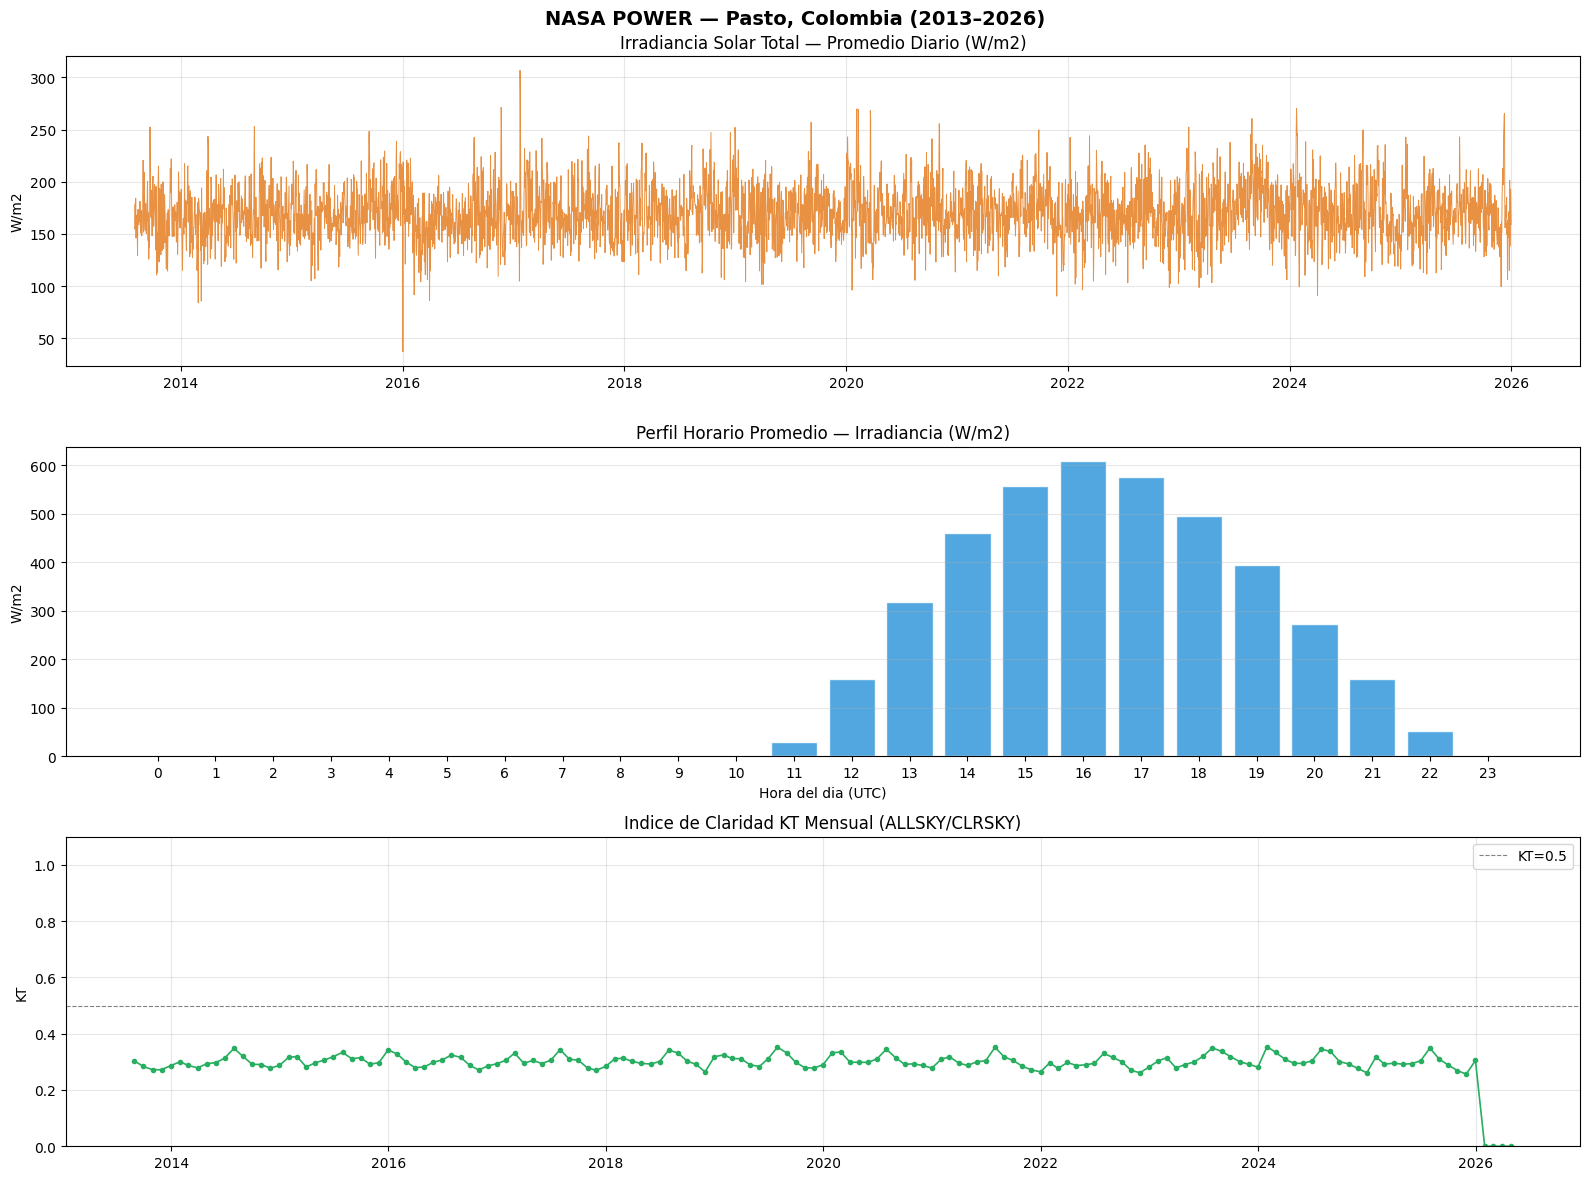

Figura guardada: /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/fig_00_nasa_power_verificacion.png


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('NASA POWER — Pasto, Colombia (2013–2026)', fontsize=14, fontweight='bold')

# Panel 1: Serie de irradiancia diaria
irr_dia = df_nasa['ALLSKY_SFC_SW_DWN'].resample('D').mean()
axes[0].plot(irr_dia.index, irr_dia.values, color='#E67E22', lw=0.7, alpha=0.85)
axes[0].set_title('Irradiancia Solar Total — Promedio Diario (W/m2)')
axes[0].set_ylabel('W/m2')
axes[0].grid(True, alpha=0.3)

# Panel 2: Perfil horario promedio
perfil = df_nasa['ALLSKY_SFC_SW_DWN'].groupby(df_nasa.index.hour).mean()
axes[1].bar(perfil.index, perfil.values, color='#3498DB', alpha=0.85, edgecolor='white')
axes[1].set_title('Perfil Horario Promedio — Irradiancia (W/m2)')
axes[1].set_ylabel('W/m2')
axes[1].set_xlabel('Hora del dia (UTC)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Indice de claridad KT mensual
kt_mes = df_nasa['KT'].resample('ME').mean()
axes[2].plot(kt_mes.index, kt_mes.values, color='#27AE60', lw=1.2, marker='o', ms=3)
axes[2].axhline(y=0.5, color='gray', linestyle='--', lw=0.8, label='KT=0.5')
axes[2].set_title('Indice de Claridad KT Mensual (ALLSKY/CLRSKY)')
axes[2].set_ylabel('KT')
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = os.path.join(RUTA_DATOS, 'fig_00_nasa_power_verificacion.png')
plt.savefig(ruta_fig, dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada:', ruta_fig)

## 9. Verificacion de cobertura temporal

In [10]:
idx_esperado  = pd.date_range(start=df_nasa.index.min(), end=df_nasa.index.max(), freq='h')
ts_ausentes   = idx_esperado.difference(df_nasa.index)

print('COBERTURA TEMPORAL')
print(f'  Esperados   : {len(idx_esperado):,}')
print(f'  Descargados : {len(df_nasa):,}')
print(f'  Ausentes    : {len(ts_ausentes):,}')

if len(ts_ausentes) == 0:
    print('  OK — Cobertura temporal completa')
else:
    print('  Primeros ausentes:', ts_ausentes[:5].tolist())

print()
print('Notebook 00 completado. Siguiente: 01_eda_estacion_cesmag.ipynb')

COBERTURA TEMPORAL
  Esperados   : 111,744
  Descargados : 111,744
  Ausentes    : 0
  OK — Cobertura temporal completa

Notebook 00 completado. Siguiente: 01_eda_estacion_cesmag.ipynb
